In [ ]:
!wget -O exp-7-1.jpg "https://www-edlab.cs.umass.edu/~smaji/cmpsci670/fa14/hw/blobs/butterfly.jpg"
!wget -O exp-7-2.jpg "https://user-images.githubusercontent.com/37275728/200141206-688cf1be-a38f-4205-b44d-977cc153b020.png"

In [97]:
import cv2
import numpy as np

In [98]:
from google.colab.patches import cv2_imshow as imshow

In [99]:
# Read the image in grayscale
img1 = cv2.imread('exp-7-1.jpg', 0)
img2 = cv2.imread('exp-7-2.jpg', cv2.IMREAD_COLOR)
img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

## Blob Detection

In [100]:
# Set up SimpleBlobDetector parameters
params = cv2.SimpleBlobDetector_Params()

# Filter by Area
params.filterByArea = True
params.minArea = 100   # Minimum area of blob

# Disable other filters
params.filterByCircularity = False
params.filterByConvexity = False
params.filterByInertia = False

In [101]:
# Create the Blob Detector
detector = cv2.SimpleBlobDetector_create(params)

# Detect blobs
keypoints = detector.detect(img1)

In [102]:
# Draw detected blobs as red circles
img_with_keypoints = cv2.drawKeypoints(
    img1,
    keypoints,
    None,
    (0, 0, 255),
    cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

BLOB DETECTION


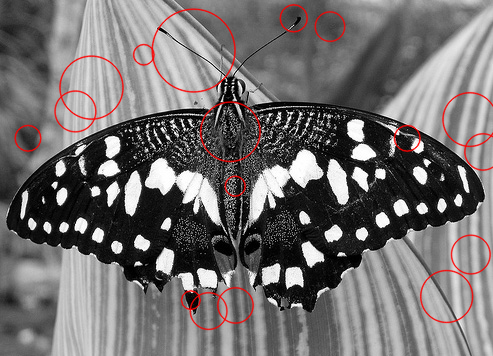

In [103]:
# Display the result
print("BLOB DETECTION")
imshow(img_with_keypoints)

## Coin Detection

In [104]:
# Apply Gaussian Blur
blurred = cv2.GaussianBlur(img2_gray, (11, 11), 0)

In [111]:
# Detect circles using Hough Transform
circles = cv2.HoughCircles(
    blurred,
    cv2.HOUGH_GRADIENT,
    dp=1.4,           # Resolution ratio (1.0 = same as input)
    minDist=50,       # Minimum distance between coin centers
    param1=100,       # Upper threshold for Canny edge detector
    param2=30,        # Accumulator threshold for circle detection (lower = more circles)
    minRadius=20,     # Minimum coin radius
    maxRadius=60      # Maximum coin radius
)

In [112]:
if circles is not None:

    circles = np.round(circles[0]).astype("int")

    for (x, y, r) in circles:
        cv2.circle(img2, (x, y), r, (0, 255, 0), 4)
        cv2.rectangle(img2, (x - 5, y - 5),
                      (x + 5, y + 5),
                      (0, 128, 255), -1)


COIN DETECTION


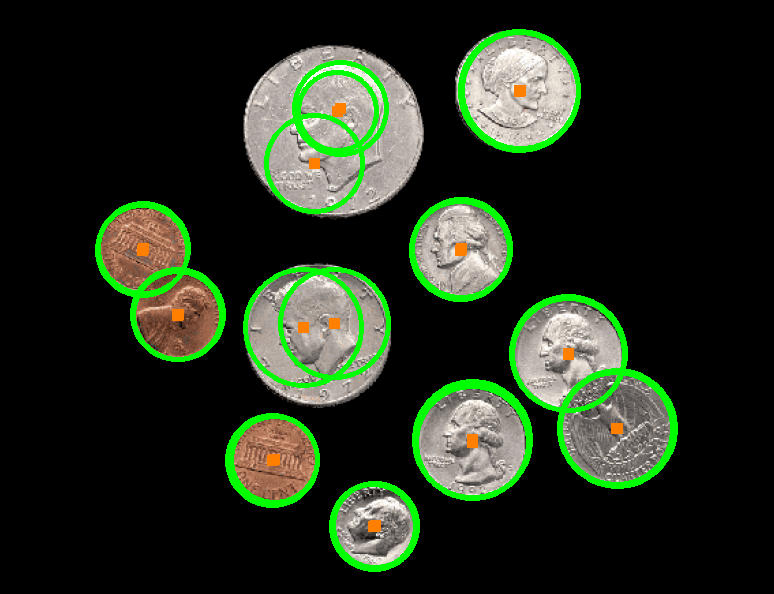

In [113]:
# Display result
print("COIN DETECTION")
imshow(img2)